<a href="https://colab.research.google.com/github/MariSegato/UFES-postgraduate-data-science-final-project/blob/main/notebooks/model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Treinando os Modelos**

## **1.1.Importações**

In [1]:
import os, random
import pandas as pd, numpy as np, random    # manipulação de dados
import json
from PIL import Image, ImageOps, ImageStat, ImageFilter
from tqdm import tqdm               # barras de progresso
import time

from google.colab import drive
from collections import Counter
import hashlib

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torchvision.models as models

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, recall_score, confusion_matrix

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


## **1.2. Funções**

In [3]:
# ======= TENSORES NORMALIZADOS PARA AS CNNs ================================================

stats_mean = [0.6641, 0.5185, 0.4603]
stats_std  = [0.1411, 0.1402, 0.1463]


# ======= TRANSFORMAÇÕES - PIPELINE DE TREINO ===============================================

train_tfms = transforms.Compose([
    # tamanho fixo (como segurança, apesar das imgs já estarem em resize)
    transforms.Resize(256),
    # entrada padrão da maioria das CNNs (224 x 224)
    transforms.CenterCrop(224),

    # augmentações geométricas simulando posições diferentes da câmera
    transforms.RandomHorizontalFlip(p=0.5),                 # espelhar horizontalmente
    transforms.RandomRotation(10),                          # rotação de +/- 10º
    transforms.ColorJitter(brightness=0.15, contrast=0.15), # simular diferentes iluminações e sensores da câmera

    # simulando zoom e fotos tremidas
    transforms.RandomResizedCrop(
        224,
        scale=(0.9, 1.1),
        ratio=(0.9, 1.1)
    ),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5)),

    # Passo final obrigatório: Converter imagem (PIL) para Tensor (PyTorch) e Normalizar
    transforms.ToTensor(),
    transforms.Normalize(mean=stats_mean, std=stats_std)
])


# ======= TRANSFORMAÇÕES - PIPELINE DE VALIDAÇÃO ============================================

eval_tfms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(), # Corrigido: adicionado () para instanciar ToTensor
    transforms.Normalize(mean=stats_mean, std=stats_std)
])


# ======= LER ARQUIVOS E IMAGENS ============================================================

class SkinLesionDataset(Dataset):
  """
  Classe personalizada para ler o dataset PAD-UFES-20.
  Herda de torch.utils.data.Dataset.
  """
  def __init__(self, metadata_df, img_dir, transform=None):
    """
    Args:
        metadata_df (pd.DataFrame): DataFrame filtrado (só treino, ou só teste).
        img_dir (str): Caminho da pasta com as imagens.
        transform (callable, optional): Pipeline de transformações a aplicar.
    """
    self.df = metadata_df.reset_index(drop=True)
    self.img_dir = img_dir
    self.transform = transform

    # # mapear classe (índice numérico)
    # self.class_to_idx = {cls: idx for idx, cls in enumerate(sorted(self.df['diagnostic'].unique()))}
    # self.idx_to_class = {v:k for k,v in self.class_to_idx.items()}

  def __len__(self):
    # Retorna o tamanho total do dataset (obrigatório pelo PyTorch)
    return len(self.df)

  def __getitem__(self, idx):
    # Este método busca UMA imagem e seu rótulo quando o DataLoader pede.

    row = self.df.iloc[idx]                               # linha correspondente no csv
    img_path = os.path.join(self.img_dir, row["img_id"])  # monta caminho completo da img

    img = Image.open(img_path).convert("RGB")             # abre img e converte para RGB

    # aplica transforações (se treino, aplica augmentação)
    if self.transform:
      img = self.transform(img)

    # cinvertendo para float32 (obrigatório para BCEWithLogitsLoss)
    label = torch.tensor([row["target_bin"]], dtype=torch.float32)        # converte para tensor

    # retorna a imagem processada (Tensor) e o rótulo (Int)
    return img, label


# ======= SEED  =============================================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# ======= MODELOS BASE - CLASSIFICAÇÃO BINÁRIA  =============================================

def make_model(model_name):
  if model_name == "resnet18":
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    in_feats = model.fc.in_features
    # model.fc = nn.Linear(in_feats, 1)
    model.fc = nn.Sequential(
        nn.Dropout(p=0.2),
        nn.Linear(in_feats, 1)
    )

  elif model_name == "resnet50":
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    in_feats = model.fc.in_features
    model.fc = nn.Linear(in_feats, 1)

  elif model_name == "efficientnet_b0":
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    in_feats = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_feats, 1)

  else:
    raise ValueError("Modelo não suportado.")

  return model


# ======= MÉTRICAS DE AVALIAÇÃO =============================================================

def evaluate_metrics(labels, probs):
  # threshold - se prob >= 0.5, classifica como maligno
  preds = (probs >= 0.5).astype(int)

  acc = accuracy_score(labels, preds)
  f1 = f1_score(labels, preds)

  # area under the ROC curve - qualidade da separação entre classes
  try:
    auroc = roc_auc_score(labels, probs)
  except:
    auroc = float('nan')

  # sensibilidade/recall/revocação - "capacidade de detectar doentes"
  sens = recall_score(labels, preds) # recall classe 1

  # especificidade - "capacidade de detectar saudáveis"
  tn, fp, fn, tp = confusion_matrix(labels, preds).ravel()
  espec = tn / (tn + fp)

  return {
      "acc": acc,
      "f1": f1,
      "auroc": auroc,
      "sens": sens,
      "espec": espec
  }


# ======= TREINO DE UMA ÉPOCA ===============================================================

def train_one_epoch(model, loader, optimizer, device):
  model.train()
  total_loss = 0

  # loop pelos minilotes/batches de dados
  for imgs, labels in loader:
      imgs = imgs.to(device)
      # Corrigido: remover .unsqueeze(1) para que o rótulo tenha o mesmo formato do logit (batch_size, 1)
      labels = labels.float().to(device)

      optimizer.zero_grad()             # Limpa os gradientes (erros) do passo anterior
      logits = model(imgs)              # Forward Pass: A rede faz as previsões (chutes)
      loss = criterion(logits, labels)  # Calcula o erro
      loss.backward()                   # Backpropagation
      optimizer.step()                  # Atualiza os pesos

      # acumula erro total (para posterior cálculo da média da época)
      total_loss += loss.item() * imgs.size(0)

  # retorna erro médio da época
  return total_loss / len(loader.dataset)


# ======= VALIDAÇÃO =========================================================================

def eval_model(model, loader, device):
  # desliga o dropout e fixa BatchNormalization (resultados estáveis e reprodutíveis)
  model.eval()
  total_loss = 0
  all_labels = []
  all_probs = []

  # desliga cálculo de gradientes
  with torch.no_grad():
    for imgs, labels in loader:
      imgs = imgs.to(device)
      # Corrigido: remover .unsqueeze(1) para que o rótulo tenha o mesmo formato do logit (batch_size, 1)
      labels = labels.float().to(device)

      # forward pass: gera previsões
      logits = model(imgs)
      # cálculo do erro, mas sem treinar
      loss = criterion(logits, labels)

      # pré-processamento das previsões
      probs = torch.sigmoid(logits).cpu().numpy().ravel()
      total_loss += loss.item() * imgs.size(0)

      all_labels.extend(labels.cpu().numpy().ravel())
      all_probs.extend(probs)

    metrics = evaluate_metrics(
        np.array(all_labels),
        np.array(all_probs)
    )

    # erro médio e dicionário com todas as métricas
    return total_loss / len(loader.dataset), metrics


# ======= LOOOP TREINAMENTO MODELO ==========================================================

def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    num_epochs=30,
    patience=5,
    model_name="model",
    save_dir="models/"
):

  os.makedirs(save_dir, exist_ok=True)
  model_path = os.path.join(save_dir, f"{model_name}.pt")

  scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=4
  )

  best_val_loss = np.inf
  best_epoch = -1
  history = {"train_loss": [], "val_loss": [], "metrics": []}

  with tqdm(range(num_epochs), unit="epoch") as pbar:
    for epoch in range(num_epochs):
      pbar.set_description(f"Epoch {epoch+1}/{num_epochs}") # Atualiza o título da barra
      t0 = time.time()

      # treino
      train_loss = train_one_epoch(model, train_loader, optimizer, device)

      # validação
      val_loss, metrics = eval_model(model, val_loader, device)
      scheduler.step(val_loss)

      # atualiza histórico
      history["train_loss"].append(train_loss)
      history["val_loss"].append(val_loss)
      history["metrics"].append(metrics)

      pbar.set_postfix(train_loss=train_loss, val_loss=val_loss, **metrics)

      print(f"\n[Epoch {epoch+1}/{num_epochs}]")
      print(f"Train Loss:  {train_loss:.4f}")
      print(f"Val Loss:    {val_loss:.4f}")
      print(f"Val metrics: {metrics}")
      print(f"Epoch time:  {time.time() - t0:.1f}s")

      # early stopping
      if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        torch.save(model.state_dict(), model_path)
        tqdm.write(f"✓ Melhor modelo salvo em epoch {epoch+1}")
      else:
        if (epoch - best_epoch) >= patience:
          tqdm.write(f"\nEarly stopping ativado. Melhor epoch: {best_epoch+1}")
          break

  # carregar melhor modelo antes de retornar
  model.load_state_dict(torch.load(model_path))
  print(f"\nModelo final carregado do epoch {best_epoch+1}")

  # salvando...
  model.load_state_dict(torch.load(model_path))

  # salvar histórico
  hist_path = os.path.join(save_dir, f"{model_name}_history.json")
  with open(hist_path, "w") as f:
      json.dump(history, f, indent=2)

  print(f"Histórico salvo em: {hist_path}")

  return model, history


## **1.3. Configurando caminhos**

In [4]:
BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/UFES Pós IA CD/10. TCC/Dataset PAD-UFES-20/"
IMG_DIR = os.path.join(BASE_PATH, "images_resize/")
SPLITS_DIR = os.path.join(BASE_PATH, "splits/")

# metadata com split anexado (para que não haja vazamento de dados/leakage) + classificaçao binária
metadata_path = os.path.join(BASE_PATH, "metadata_target_bin.csv")
metadata = pd.read_csv(metadata_path)

In [15]:
metadata["target_bin"].value_counts(normalize=True) # verificando

,proportion
target_bin,
0,0.52611
1,0.47389


In [18]:
metadata.columns

Index(['Unnamed: 0', 'patient_id', 'lesion_id', 'smoke', 'drink',
       'background_father', 'background_mother', 'age', 'pesticide', 'gender',
       'skin_cancer_history', 'cancer_history', 'has_piped_water',
       'has_sewage_system', 'fitspatrick', 'region', 'diameter_1',
       'diameter_2', 'diagnostic', 'itch', 'grew', 'hurt', 'changed', 'bleed',
       'elevation', 'img_id', 'biopsed', 'diagnostic_group', 'width', 'height',
       'area', 'aspect_ratio', 'min_dim', 'color_mode', 'file_hash',
       'brightness', 'focus_var', 'low_quality', 'split', 'target_bin'],
      dtype='object')

In [5]:
df_train = metadata[metadata["split"] == "train"]
df_val = metadata[metadata["split"] == "val"]
df_test = metadata[metadata["split"] == "test"]

train_dataset = SkinLesionDataset(df_train, IMG_DIR, transform=train_tfms)
val_dataset = SkinLesionDataset(df_val, IMG_DIR, transform=eval_tfms)
test_dataset = SkinLesionDataset(df_test, IMG_DIR, transform=eval_tfms)

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,           # embaralha os dados a cada época para que a rede não decore a ordem
    num_workers=2,          # 2 subprocessos em paralelo para carregar dados
    pin_memory=True         # otimiza a transferência de ddoso da RAM para a VRAM (GPU)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,          # não é necessário embaralhar validação
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,         # não embaralhar
    num_workers=2,
    pin_memory=True
)

criterion = nn.BCEWithLogitsLoss()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

set_seed(42)

model = make_model("resnet18").to(device)

# Freeze all parameters
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

# optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 166MB/s]


## **1.4. aaa**

In [14]:
print(device)

cuda


In [6]:
model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    num_epochs=50,
    patience=40,
    model_name="resnet18_bin",
    save_dir="models/"
)

Epoch 2/50:   0%|          | 0/50 [06:32<?, ?epoch/s, acc=0.549, auroc=0.581, espec=0.5, f1=0.573, sens=0.598, train_loss=0.72, val_loss=0.689]


[Epoch 1/50]
Train Loss:  0.7205
Val Loss:    0.6887
Val metrics: {'acc': 0.5494186046511628, 'f1': 0.5730027548209367, 'auroc': np.float64(0.581288032454361), 'sens': 0.5977011494252874, 'espec': np.float64(0.5)}
Epoch time:  392.9s
✓ Melhor modelo salvo em epoch 1


Epoch 3/50:   0%|          | 0/50 [06:53<?, ?epoch/s, acc=0.602, auroc=0.624, espec=0.594, f1=0.607, sens=0.609, train_loss=0.696, val_loss=0.672]


[Epoch 2/50]
Train Loss:  0.6958
Val Loss:    0.6720
Val metrics: {'acc': 0.6017441860465116, 'f1': 0.6074498567335244, 'auroc': np.float64(0.6237153482082488), 'sens': 0.6091954022988506, 'espec': np.float64(0.5941176470588235)}
Epoch time:  20.6s
✓ Melhor modelo salvo em epoch 2


Epoch 4/50:   0%|          | 0/50 [07:16<?, ?epoch/s, acc=0.622, auroc=0.66, espec=0.594, f1=0.635, sens=0.649, train_loss=0.683, val_loss=0.655]

...


[Epoch 48/50]
Train Loss:  0.5279
Val Loss:    0.5127
Val metrics: {'acc': 0.7558139534883721, 'f1': 0.7572254335260116, 'auroc': np.float64(0.8294962812711292), 'sens': 0.7528735632183908, 'espec': np.float64(0.7588235294117647)}
Epoch time:  20.9s
✓ Melhor modelo salvo em epoch 48


Epoch 50/50:   0%|          | 0/50 [24:04<?, ?epoch/s, acc=0.759, auroc=0.827, espec=0.771, f1=0.758, sens=0.747, train_loss=0.523, val_loss=0.513]


[Epoch 49/50]
Train Loss:  0.5229
Val Loss:    0.5129
Val metrics: {'acc': 0.7587209302325582, 'f1': 0.7580174927113703, 'auroc': np.float64(0.8273664638269101), 'sens': 0.7471264367816092, 'espec': np.float64(0.7705882352941177)}
Epoch time:  22.5s


Epoch 50/50:   0%|          | 0/50 [24:25<?, ?epoch/s, acc=0.753, auroc=0.831, espec=0.782, f1=0.748, sens=0.724, train_loss=0.541, val_loss=0.51]



[Epoch 50/50]
Train Loss:  0.5411
Val Loss:    0.5099
Val metrics: {'acc': 0.752906976744186, 'f1': 0.7477744807121661, 'auroc': np.float64(0.8313894523326572), 'sens': 0.7241379310344828, 'espec': np.float64(0.7823529411764706)}
Epoch time:  21.2s
✓ Melhor modelo salvo em epoch 50

Modelo final carregado do epoch 50
Histórico salvo em: models/resnet18_bin_history.json


In [7]:
print(history.keys())

dict_keys(['train_loss', 'val_loss', 'metrics'])


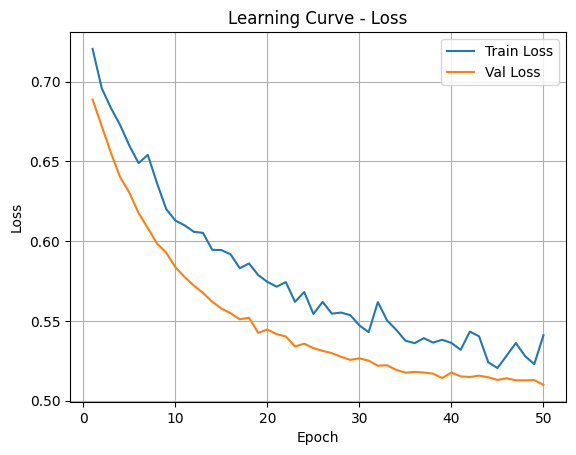

In [8]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure()
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curve - Loss")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
import json

# Assuming 'history' is a Keras History object or a dictionary of metrics
# If 'history' is a Keras History object, its metrics are in history.history
history_data = history.history if hasattr(history, 'history') else history

with open('training_history.json', 'w') as f:
    json.dump(history_data, f, indent=4)

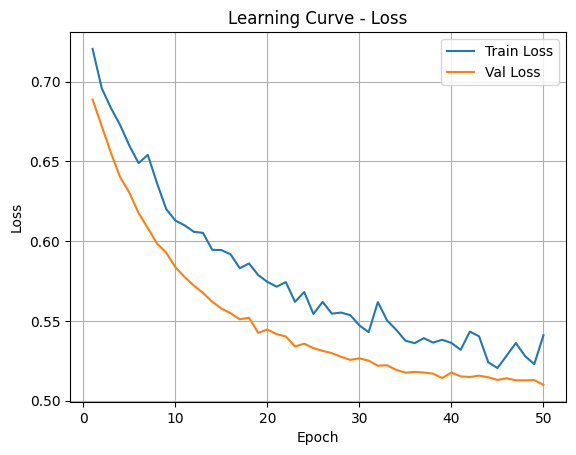

In [10]:
# load history
import json

def plot_history(fname):
    with open(fname) as f:
        history = json.load(f)

    import matplotlib.pyplot as plt

    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Learning Curve - Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history("training_history.json")

In [ ]:
plot_history("training_history_sem_droput_freeze_all_but_1.json")